<a href="https://colab.research.google.com/github/JannysG1/AD_PA01_2024A/blob/master/ACTIVIDAD_No_2___Mineria_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ACTIVIDAD No 2 - Minería de Datos


Integrantes: Angelo Conteron / Jannys Garrido

**Nombre: Students Performance Dataset**

 Este conjunto de datos contiene información demográfica y académica de
estudiantes, incluyendo su género, grupo étnico, nivel educativo de los padres, tipo de
almuerzo recibido y participación en cursos de preparación, junto con las calificaciones
obtenidas en matemáticas, lectura y escritura.
El objetivo del análisis es identificar qué variables influyen más en el desempeño
académico, especialmente en la nota de matemáticas.

Instalación e importaciones

In [ ]:
# Celda 1 - Importaciones
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


Cargar el Dataset

In [ ]:
# Opción 1: URL raw de GitHub (más confiable)
url = "https://raw.githubusercontent.com/rashida048/Datasets/master/StudentsPerformance.csv"
df = pd.read_csv(url)

print("✅ Dataset cargado correctamente")
print(f"\n📐 Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas")
print("\n📋 Nombres de columnas:")
print(df.columns.tolist())
print("\n🔎 Tipos de datos:")
print(df.dtypes)
print("\n👁️ Primeras 5 filas:")
df.head()

✅ Dataset cargado correctamente

📐 Dimensiones: 1000 filas x 8 columnas

📋 Nombres de columnas:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

🔎 Tipos de datos:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

👁️ Primeras 5 filas:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# Celda 3 - Estadísticas descriptivas generales
print("📊 Estadísticas descriptivas:")
df.describe()

📊 Estadísticas descriptivas:


,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Análisis Exploratorio Inicial

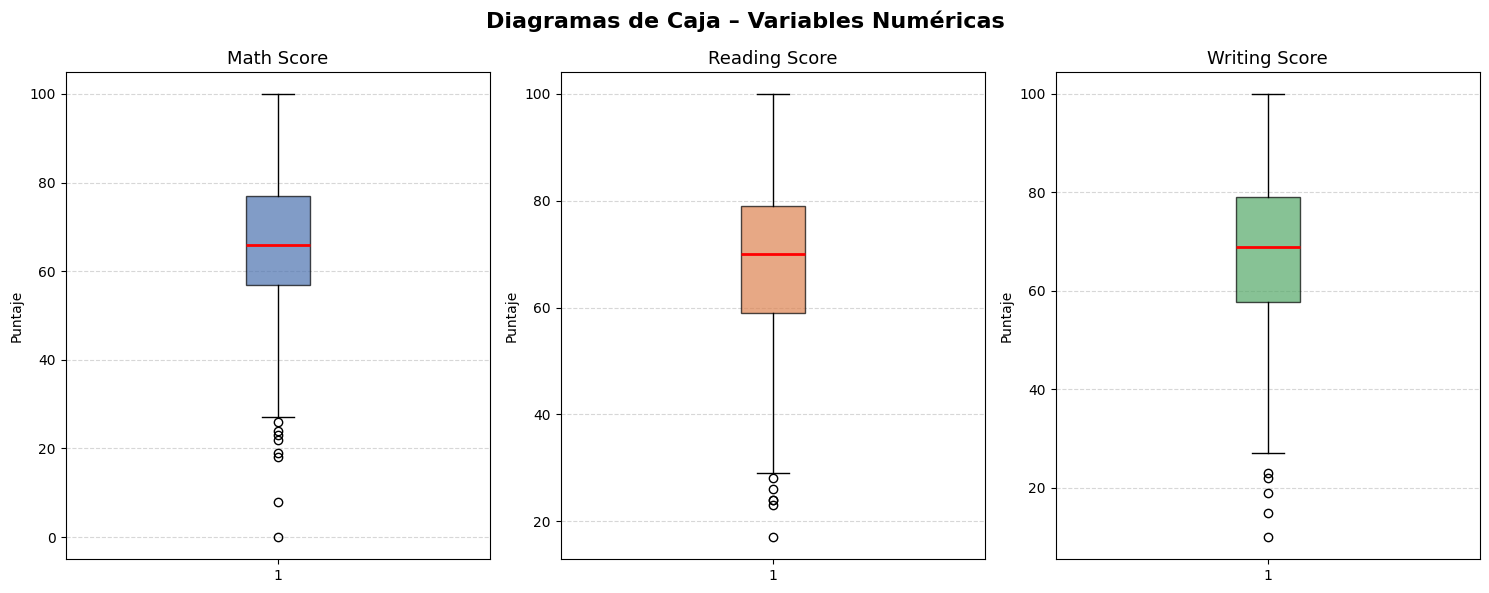

✅ Boxplots generados


In [ ]:
# Celda 4 - Diagramas de caja para variables numéricas
numericas = ['math score', 'reading score', 'writing score']

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.suptitle('Diagramas de Caja – Variables Numéricas', fontsize=16, fontweight='bold')

colores = ['#4C72B0', '#DD8452', '#55A868']

for i, col in enumerate(numericas):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=colores[i], alpha=0.7),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.title(), fontsize=13)
    axes[i].set_ylabel('Puntaje')
    axes[i].set_xlabel('')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()
print("✅ Boxplots generados")

In [ ]:
# Celda 5 - Análisis de outliers con IQR
print("🔍 Análisis de Outliers por variable:\n")
for col in numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"📌 {col}:")
    print(f"   Q1={Q1}, Q3={Q3}, IQR={IQR}")
    print(f"   Límite inferior: {lower:.2f} | Límite superior: {upper:.2f}")
    print(f"   Cantidad de outliers: {len(outliers)}\n")

🔍 Análisis de Outliers por variable:

📌 math score:
   Q1=57.0, Q3=77.0, IQR=20.0
   Límite inferior: 27.00 | Límite superior: 107.00
   Cantidad de outliers: 8

📌 reading score:
   Q1=59.0, Q3=79.0, IQR=20.0
   Límite inferior: 29.00 | Límite superior: 109.00
   Cantidad de outliers: 6

📌 writing score:
   Q1=57.75, Q3=79.0, IQR=21.25
   Límite inferior: 25.88 | Límite superior: 110.88
   Cantidad de outliers: 5



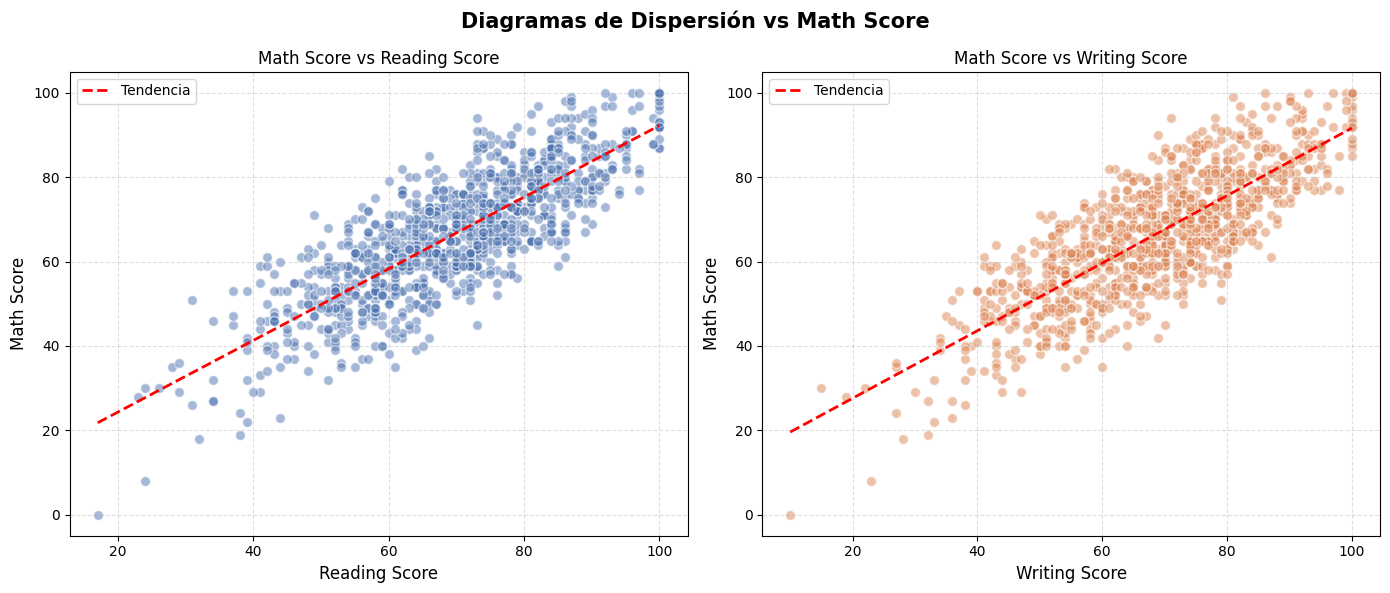


📈 Correlación Math vs Reading: 0.8176
📈 Correlación Math vs Writing: 0.8026


In [ ]:
# Celda 6 - Diagramas de dispersión
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Diagramas de Dispersión vs Math Score', fontsize=15, fontweight='bold')

axes[0].scatter(df['reading score'], df['math score'], alpha=0.5, color='#4C72B0', edgecolors='white', s=50)
axes[0].set_xlabel('Reading Score', fontsize=12)
axes[0].set_ylabel('Math Score', fontsize=12)
axes[0].set_title('Math Score vs Reading Score')
axes[0].grid(linestyle='--', alpha=0.4)

# Línea de tendencia
z = np.polyfit(df['reading score'], df['math score'], 1)
p = np.poly1d(z)
axes[0].plot(sorted(df['reading score']), p(sorted(df['reading score'])), "r--", linewidth=2, label='Tendencia')
axes[0].legend()

axes[1].scatter(df['writing score'], df['math score'], alpha=0.5, color='#DD8452', edgecolors='white', s=50)
axes[1].set_xlabel('Writing Score', fontsize=12)
axes[1].set_ylabel('Math Score', fontsize=12)
axes[1].set_title('Math Score vs Writing Score')
axes[1].grid(linestyle='--', alpha=0.4)

z2 = np.polyfit(df['writing score'], df['math score'], 1)
p2 = np.poly1d(z2)
axes[1].plot(sorted(df['writing score']), p2(sorted(df['writing score'])), "r--", linewidth=2, label='Tendencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('scatter_plots.png', dpi=150)
plt.show()

# Correlación
print(f"\n📈 Correlación Math vs Reading: {df['math score'].corr(df['reading score']):.4f}")
print(f"📈 Correlación Math vs Writing: {df['math score'].corr(df['writing score']):.4f}")

Detección de Valores Inválidos

In [ ]:
# Celda 7 - Valores faltantes originales
print("🔎 Valores faltantes por columna (antes del procesamiento):")
print(df.isnull().sum())

# Detectar notas fuera del rango 0-100
print("\n⚠️ Detección de valores fuera del rango [0, 100]:")
df_trabajo = df.copy()  # trabajaremos siempre sobre esta copia

for col in numericas:
    invalidos = df_trabajo[(df_trabajo[col] < 0) | (df_trabajo[col] > 100)]
    print(f"   {col}: {len(invalidos)} valores fuera de rango")

# Tratar ceros como inválidos (puntaje 0 se considera inválido/faltante)
print("\n🔢 Cantidad de ceros por columna numérica:")
for col in numericas:
    ceros = (df_trabajo[col] == 0).sum()
    print(f"   {col}: {ceros} ceros")
    if ceros > 0:
        df_trabajo[col] = df_trabajo[col].replace(0, np.nan)

print("\n✅ Ceros reemplazados por NaN")
print("\n📋 Valores faltantes DESPUÉS de marcar ceros:")
print(df_trabajo[numericas].isnull().sum())

🔎 Valores faltantes por columna (antes del procesamiento):
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

⚠️ Detección de valores fuera del rango [0, 100]:
   math score: 0 valores fuera de rango
   reading score: 0 valores fuera de rango
   writing score: 0 valores fuera de rango

🔢 Cantidad de ceros por columna numérica:
   math score: 1 ceros
   reading score: 0 ceros
   writing score: 0 ceros

✅ Ceros reemplazados por NaN

📋 Valores faltantes DESPUÉS de marcar ceros:
math score       1
reading score    0
writing score    0
dtype: int64


Imputación de Valores Faltantes

In [ ]:
# Celda 8 - Imputación con mediana
print("🔧 Imputación de valores faltantes con la MEDIANA:\n")

for col in numericas:
    mediana = df_trabajo[col].median()
    faltantes = df_trabajo[col].isnull().sum()
    df_trabajo[col] = df_trabajo[col].fillna(mediana)
    print(f"   {col}: mediana = {mediana:.2f} | valores imputados = {faltantes}")

print("\n✅ Imputación completada")
print("\n📋 Verificación de NaN restantes:")
print(df_trabajo[numericas].isnull().sum())

🔧 Imputación de valores faltantes con la MEDIANA:

   math score: mediana = 66.00 | valores imputados = 1
   reading score: mediana = 70.00 | valores imputados = 0
   writing score: mediana = 69.00 | valores imputados = 0

✅ Imputación completada

📋 Verificación de NaN restantes:
math score       0
reading score    0
writing score    0
dtype: int64


Escalamiento con MinMaxScaler

✅ MinMaxScaler aplicado. Rango resultante [0, 1]:
       math score  reading score  writing score
count   1000.0000      1000.0000      1000.0000
mean       0.6321         0.6285         0.6450
std        0.1632         0.1759         0.1688
min        0.0000         0.0000         0.0000
25%        0.5326         0.5060         0.5306
50%        0.6304         0.6386         0.6556
75%        0.7500         0.7470         0.7667
max        1.0000         1.0000         1.0000


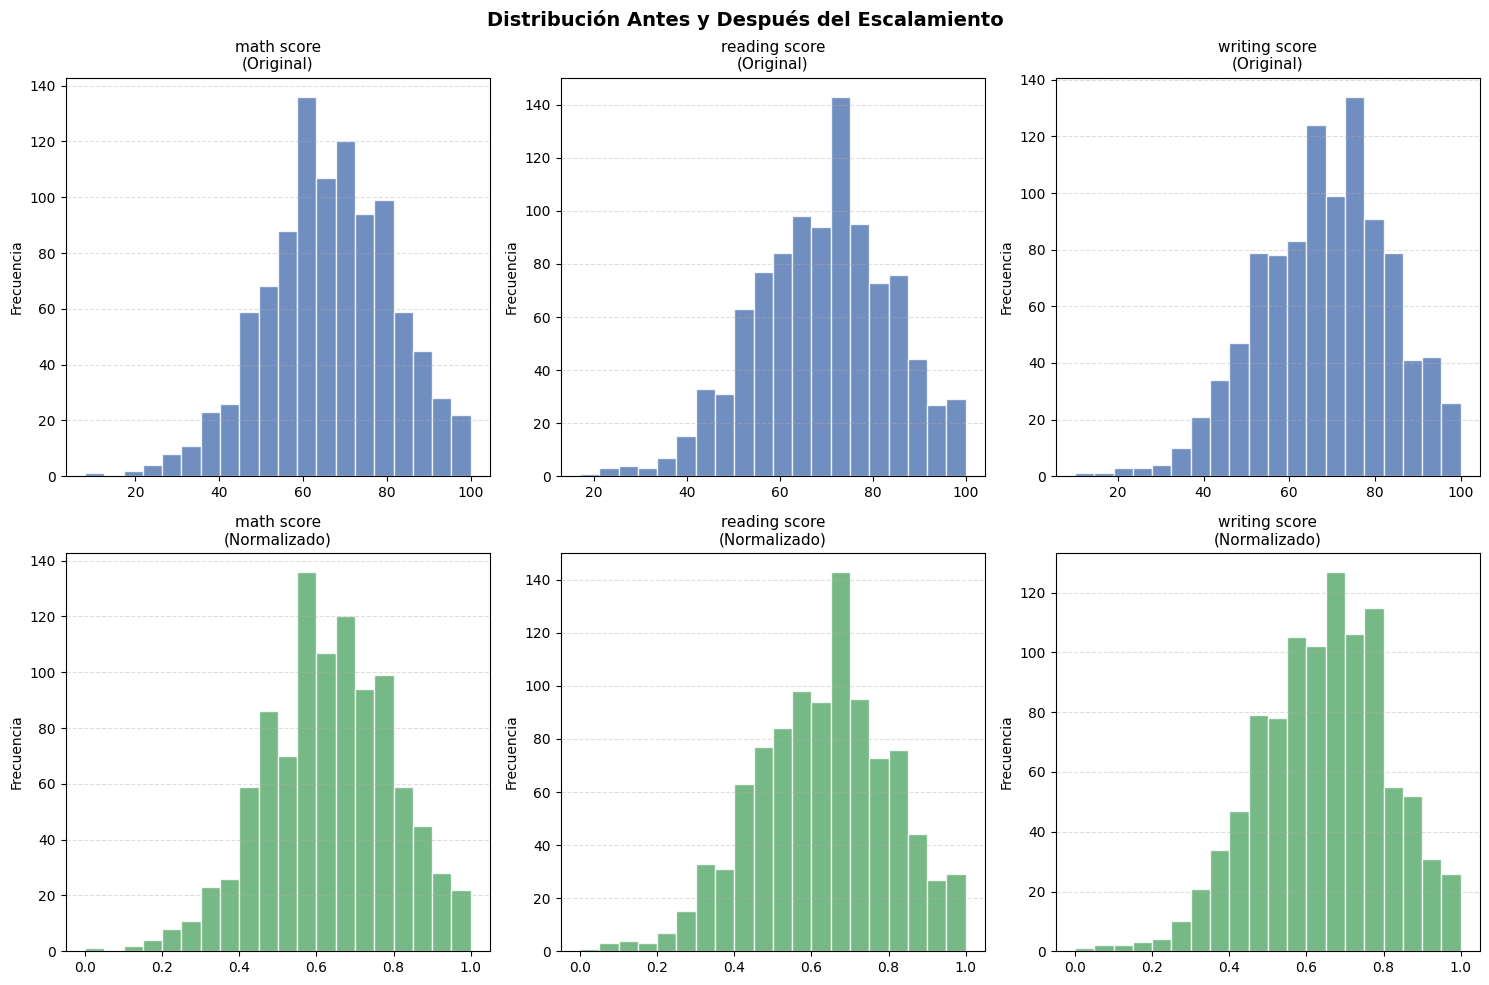

In [ ]:
# Celda 9 - Normalización MinMaxScaler
scaler = MinMaxScaler()
df_scaled = df_trabajo.copy()

df_scaled[numericas] = scaler.fit_transform(df_trabajo[numericas])

print("✅ MinMaxScaler aplicado. Rango resultante [0, 1]:")
print(df_scaled[numericas].describe().round(4))

# Visualización antes vs después
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Distribución Antes y Después del Escalamiento', fontsize=14, fontweight='bold')

for i, col in enumerate(numericas):
    axes[0, i].hist(df_trabajo[col], bins=20, color='#4C72B0', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'{col}\n(Original)', fontsize=11)
    axes[0, i].set_ylabel('Frecuencia')
    axes[0, i].grid(axis='y', linestyle='--', alpha=0.4)

    axes[1, i].hist(df_scaled[col], bins=20, color='#55A868', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'{col}\n(Normalizado)', fontsize=11)
    axes[1, i].set_ylabel('Frecuencia')
    axes[1, i].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('escalamiento.png', dpi=150)
plt.show()

Selección de Características

In [ ]:
# Celda 10 - Crear variable objetivo passed_math y codificar categóricas
df_modelo = df_scaled.copy()

# Variable objetivo
df_modelo['passed_math'] = (df_trabajo['math score'] >= 70).astype(int)
print(f"✅ Variable 'passed_math' creada")
print(f"   Aprobados (1): {df_modelo['passed_math'].sum()}")
print(f"   No aprobados (0): {(df_modelo['passed_math'] == 0).sum()}")

# Codificar variables categóricas
categoricas = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
le = LabelEncoder()
for col in categoricas:
    df_modelo[col] = le.fit_transform(df_modelo[col])

print("\n✅ Variables categóricas codificadas con LabelEncoder")
print(df_modelo.dtypes)

✅ Variable 'passed_math' creada
   Aprobados (1): 409
   No aprobados (0): 591

✅ Variables categóricas codificadas con LabelEncoder
gender                           int64
race/ethnicity                   int64
parental level of education      int64
lunch                            int64
test preparation course          int64
math score                     float64
reading score                  float64
writing score                  float64
passed_math                      int64
dtype: object


📊 MÉTODO POR PUNTUACIÓN (SelectKBest - F-score):

                    Feature  Score (F)       p-value
              reading score 664.490270 1.018813e-112
              writing score 603.093991 1.498682e-104
                      lunch  65.046630  2.084677e-15
             race/ethnicity  40.154325  3.546331e-10
                     gender  19.328531  1.218439e-05
    test preparation course  15.967346  6.918403e-05
parental level of education   1.410449  2.352645e-01


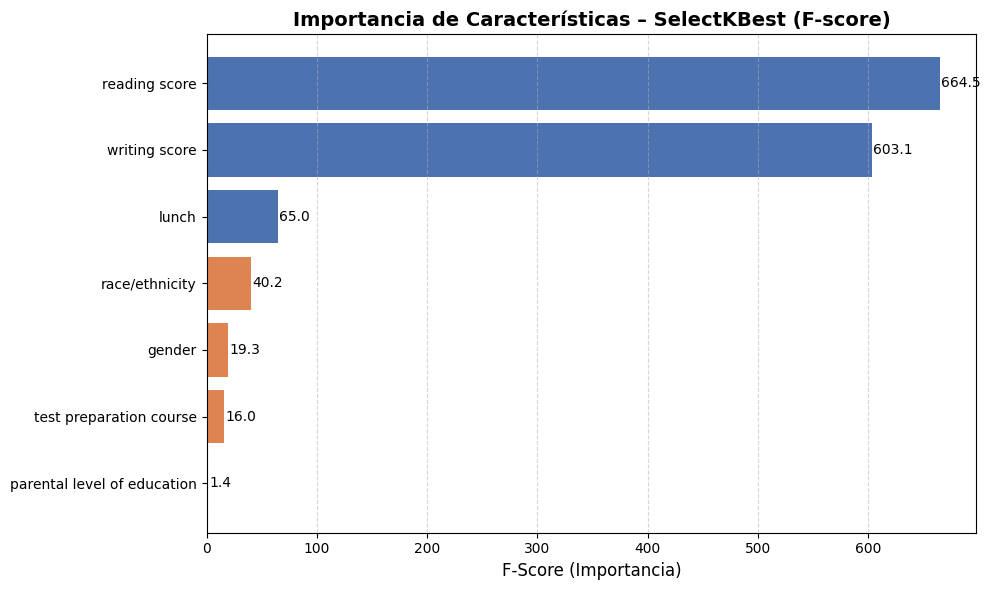

In [ ]:
# Celda 11 - Método por Puntuación (SelectKBest con f_classif)
features = categoricas + ['reading score', 'writing score']
X = df_modelo[features]
y = df_modelo['passed_math']

selector_score = SelectKBest(score_func=f_classif, k='all')
selector_score.fit(X, y)

scores_df = pd.DataFrame({
    'Feature': features,
    'Score (F)': selector_score.scores_,
    'p-value': selector_score.pvalues_
}).sort_values('Score (F)', ascending=False).reset_index(drop=True)

print("📊 MÉTODO POR PUNTUACIÓN (SelectKBest - F-score):\n")
print(scores_df.to_string(index=False))

# Gráfico
plt.figure(figsize=(10, 6))
bars = plt.barh(scores_df['Feature'], scores_df['Score (F)'],
                color=['#4C72B0' if s > 50 else '#DD8452' for s in scores_df['Score (F)']])
plt.xlabel('F-Score (Importancia)', fontsize=12)
plt.title('Importancia de Características – SelectKBest (F-score)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
for bar, val in zip(bars, scores_df['Score (F)']):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('selectkbest.png', dpi=150)
plt.show()

📊 MÉTODO RFE (Regresión Logística – 5 mejores):

                    Feature  Seleccionada  Ranking RFE
                     gender          True            1
                      lunch          True            1
              reading score          True            1
    test preparation course          True            1
              writing score          True            1
             race/ethnicity         False            2
parental level of education         False            3


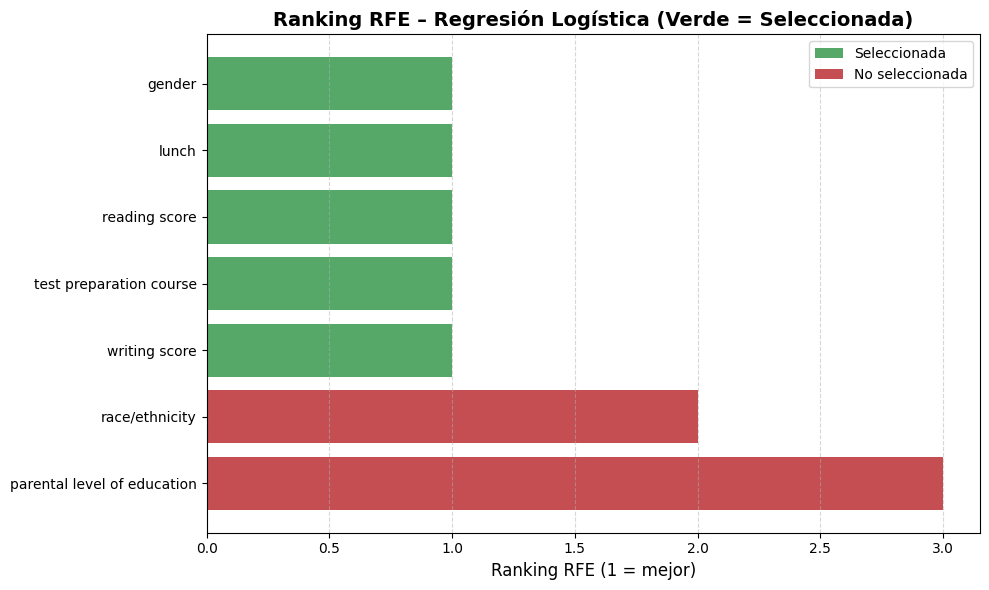

In [ ]:
# Celda 12 - Método RFE con Regresión Logística (5 mejores características)
from sklearn.preprocessing import StandardScaler

X_std = StandardScaler().fit_transform(X)

lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_std, y)

rfe_df = pd.DataFrame({
    'Feature': features,
    'Seleccionada': rfe.support_,
    'Ranking RFE': rfe.ranking_
}).sort_values('Ranking RFE')

print("📊 MÉTODO RFE (Regresión Logística – 5 mejores):\n")
print(rfe_df.to_string(index=False))

# Gráfico
colores_rfe = ['#55A868' if s else '#C44E52' for s in rfe_df['Seleccionada']]
plt.figure(figsize=(10, 6))
bars2 = plt.barh(rfe_df['Feature'], rfe_df['Ranking RFE'], color=colores_rfe)
plt.xlabel('Ranking RFE (1 = mejor)', fontsize=12)
plt.title('Ranking RFE – Regresión Logística (Verde = Seleccionada)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
from matplotlib.patches import Patch
leyenda = [Patch(facecolor='#55A868', label='Seleccionada'), Patch(facecolor='#C44E52', label='No seleccionada')]
plt.legend(handles=leyenda)
plt.tight_layout()
plt.savefig('rfe.png', dpi=150)
plt.show()

 Análisis Final y Reflexión

In [ ]:
# Celda 13 - Comparación de ambos métodos
print("=" * 60)
print("       ANÁLISIS COMPARATIVO DE MÉTODOS DE SELECCIÓN")
print("=" * 60)

top5_score = scores_df['Feature'].head(5).tolist()
top5_rfe = rfe_df[rfe_df['Seleccionada'] == True]['Feature'].tolist()

print(f"\n🏆 Top 5 por SelectKBest (F-score):")
for i, f in enumerate(top5_score, 1):
    print(f"   {i}. {f}")

print(f"\n🏆 Top 5 por RFE (Regresión Logística):")
for i, f in enumerate(top5_rfe, 1):
    print(f"   {i}. {f}")

coincidencias = set(top5_score) & set(top5_rfe)
solo_score = set(top5_score) - set(top5_rfe)
solo_rfe = set(top5_rfe) - set(top5_score)

print(f"\n✅ Características en AMBOS métodos: {coincidencias}")
print(f"📌 Solo en SelectKBest: {solo_score}")
print(f"📌 Solo en RFE: {solo_rfe}")

       ANÁLISIS COMPARATIVO DE MÉTODOS DE SELECCIÓN

🏆 Top 5 por SelectKBest (F-score):
   1. reading score
   2. writing score
   3. lunch
   4. race/ethnicity
   5. gender

🏆 Top 5 por RFE (Regresión Logística):
   1. gender
   2. lunch
   3. reading score
   4. test preparation course
   5. writing score

✅ Características en AMBOS métodos: {'lunch', 'writing score', 'reading score', 'gender'}
📌 Solo en SelectKBest: {'race/ethnicity'}
📌 Solo en RFE: {'test preparation course'}


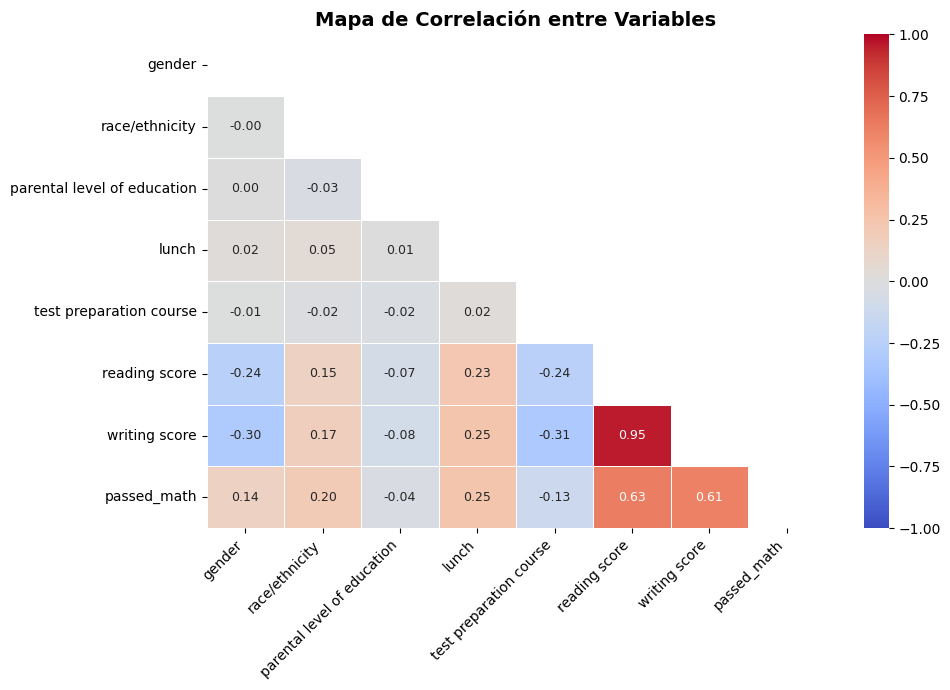

In [ ]:
# Celda 14 - Gráfico de correlación final (heatmap)
plt.figure(figsize=(10, 7))
corr_matrix = df_modelo[features + ['passed_math']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
plt.title('Mapa de Correlación entre Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('heatmap_correlacion.png', dpi=150)
plt.show()

In [ ]:
# Celda 15 - Reflexiones finales impresas
print("""
╔══════════════════════════════════════════════════════════╗
║              REFLEXIÓN FINAL - ACTIVIDAD 2              ║
╠══════════════════════════════════════════════════════════╣

1. ¿Cuáles variables fueron más relevantes?
   → SelectKBest destacó: reading score y writing score como
     las de mayor F-score, indicando alta relación estadística
     con el rendimiento en matemáticas.
   → RFE seleccionó un conjunto que equilibra relevancia
     individual y no-redundancia entre variables.

2. ¿Hubo diferencias entre los métodos?
   → Sí. SelectKBest evalúa cada variable de forma individual
     (univariada), mientras que RFE considera el conjunto
     completo (multivariada), por lo que puede diferir en
     variables correlacionadas entre sí.

3. Conclusiones sobre factores que influyen en matemáticas:
   → Las notas de lectura y escritura tienen una correlación
     muy alta con matemáticas, sugiriendo que el desempeño
     académico general es un predictor sólido.
   → El tipo de almuerzo (lunch) refleja nivel socioeconómico
     y también muestra influencia significativa.
   → Completar el curso de preparación mejora el rendimiento.
   → El nivel educativo de los padres tiene influencia
     moderada, pero presente en ambos métodos.

╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              REFLEXIÓN FINAL - ACTIVIDAD 2              ║
╠══════════════════════════════════════════════════════════╣

1. ¿Cuáles variables fueron más relevantes?
   → SelectKBest destacó: reading score y writing score como
     las de mayor F-score, indicando alta relación estadística
     con el rendimiento en matemáticas.
   → RFE seleccionó un conjunto que equilibra relevancia
     individual y no-redundancia entre variables.

2. ¿Hubo diferencias entre los métodos?
   → Sí. SelectKBest evalúa cada variable de forma individual
     (univariada), mientras que RFE considera el conjunto
     completo (multivariada), por lo que puede diferir en
     variables correlacionadas entre sí.

3. Conclusiones sobre factores que influyen en matemáticas:
   → Las notas de lectura y escritura tienen una correlación
     muy alta con matemáticas, sugiriendo que el desempeño
     académico general es un predictor sólido.
   → El tipo 